<a href="https://colab.research.google.com/github/chasekrisko-design/IT480-FA26/blob/main/Assignment1/Assignment1_Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [2]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

# Part A: Restate Your Baseline

In [3]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [4]:
# Bucket raw quality scores into 3 bands: low / medium / high
def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

# Q: How many classes do we have now? Are they reasonably balanced?
# Your answer:We have three classes being low, medium, and high. They are reasonably balanced although the high category has far less than the other two.


quality_band
0    744
1    638
2    217
Name: count, dtype: int64


In [5]:
X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

In [6]:
n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential(
    [
        tf.keras.layers.Dense(64, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax")
    ]
)

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])



/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


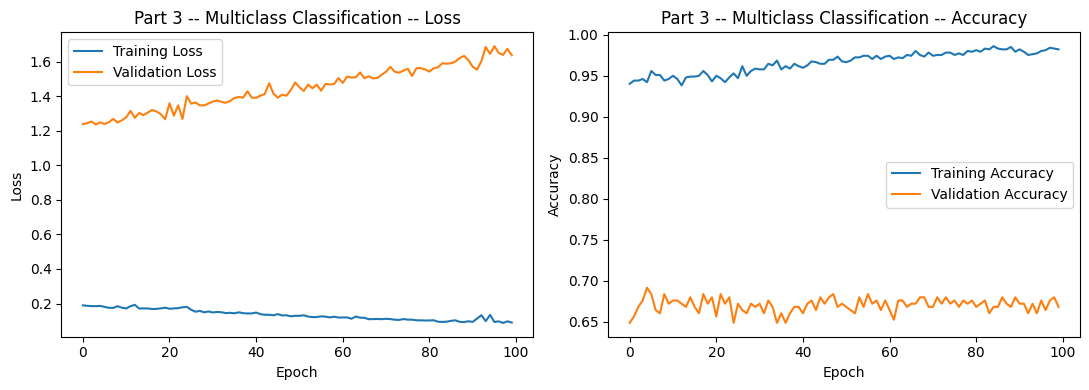

In [15]:
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)

2. The graph shows overfitting. The training loss in the loss curve was continuously going down which mens the model was successfully learning the training data. However the validation loss was going down but at about 20 Epochs the validation loss started going up which shows overfitting as the gap between the training and validation loss grew.

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.694


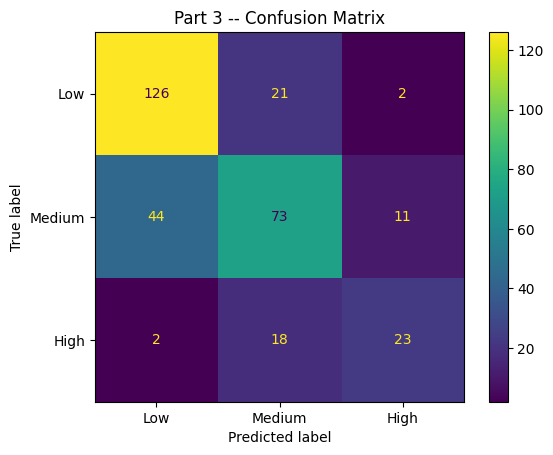

In [8]:
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()


# Part B: Hyperparameter Tuning

In [9]:
# 1
!pip install keras-tuner --quiet
import keras_tuner as kt

n_features = X3_train_scaled.shape[1]

def build_model(hp):
  model = tf.keras.Sequential([
    tf.keras.layers.Dense(
    hp.Int("hidden1", min_value=16, max_value=128, step=16),
    activation="relu", input_shape=(n_features,)
    ),
    tf.keras.layers.Dense(
      hp.Int("hidden2", min_value=8, max_value=64, step=8),
      activation="relu"
    ),
    tf.keras.layers.Dense(n_classes, activation="softmax")
  ])
  model.compile(
    optimizer=tf.keras.optimizers.Adam(
      hp.Choice("learning_rate", [0.001, 0.01, 0.1])
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
  )
  return model

tuner = kt.RandomSearch(
  build_model,
  objective="val_loss",
  max_trials=5,
  overwrite=True
)

tuner.search(
  X3_train_scaled, y3_train,
  validation_split=0.2, epochs=50, verbose=0
)
best_model = tuner.get_best_models(num_models=1)[0]
best_hp = tuner.get_best_hyperparameters(1)[0]
print(best_hp.values)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.2 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'hidden1': 112, 'hidden2': 48, 'learning_rate': 0.001}


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [11]:
best_trial = tuner.oracle.get_best_trials(num_trials=1)[0]
best_hp_values = best_trial.hyperparameters.values
best_val_loss = best_trial.score

print(f"Best Hyperparameters: {best_hp_values}")
print(f"Best Validation Loss: {best_val_loss:.4f}")

Best Hyperparameters: {'hidden1': 112, 'hidden2': 48, 'learning_rate': 0.001}
Best Validation Loss: 0.7450


The best Hyperparameters are hidden1: 16, hidden2: 48, and learning_rate: 0.01. With a validation loss of 0.7490

Final Model Test Accuracy: 0.6938
Final Model Test Loss: 0.8777


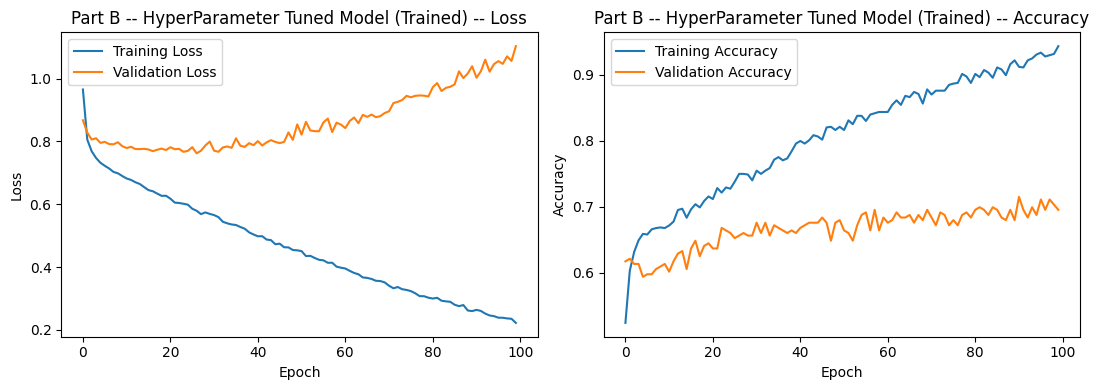

In [12]:
final_model = tuner.hypermodel.build(best_hp)

history_final = final_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)


plot_history(history_final, "Part B -- HyperParameter Tuned Model (Trained)", show_accuracy=True)

Final Model Test Accuracy: 0.6938


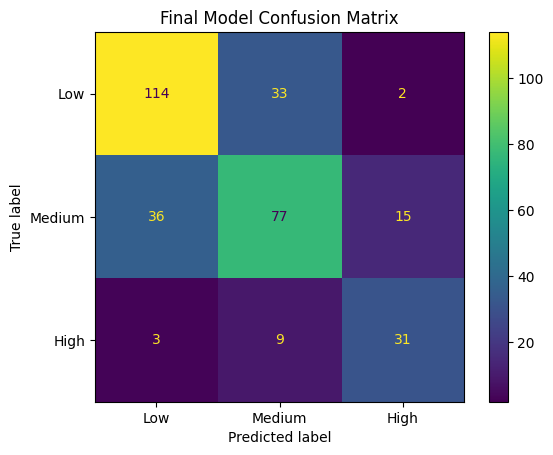

In [14]:
final_model_preds = np.argmax(final_model.predict(X3_test_scaled, verbose=0), axis=1)

cm_final = confusion_matrix(y3_test, final_model_preds)
ConfusionMatrixDisplay(cm_final, display_labels=["Low", "Medium", "High"]).plot()
loss, accuracy = final_model.evaluate(X3_test_scaled, y3_test, verbose=0)
print(f"Final Model Test Accuracy: {accuracy:.4f}")
plt.title("Final Model Confusion Matrix")
plt.show()

5. Compare models

Comparing these two, the hyperparameter-tuned model 0.6938 did not improve the accuracy upon the original baseline model which was 0.694. However, it performed slightly worse by 0.0002.

# Part 3: Addressing Overfitting

In [ ]:
def build_model_with_regularization(hp):
  model = tf.keras.Sequential([
    tf.keras.layers.Dense(
    hp.Int("hidden1", min_value=16, max_value=128, step=16),
    activation="relu", input_shape=(n_features,)
    ),
    tf.keras.layers.Dropout(hp.Float("dropout1", min_value=0.1, max_value=0.5, step=0.1)),
    tf.keras.layers.Dense(
      hp.Int("hidden2", min_value=8, max_value=64, step=8),
      activation="relu"
    ),
    tf.keras.layers.Dropout(hp.Float("dropout2", min_value=0.1, max_value=0.5, step=0.1)),
    tf.keras.layers.Dense(n_classes, activation="softmax")
  ])
  model.compile(
    optimizer=tf.keras.optimizers.Adam(
      hp.Choice("learning_rate", [0.001, 0.01, 0.1])
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
  )
  return model

tuner_regularized = kt.RandomSearch(
  build_model_with_regularization,
  objective="val_loss",
  max_trials=5,
  overwrite=True,
  directory='my_dir',
  project_name='wine_quality_regularized'
)

# Define Early Stopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

tuner_regularized.search(
  X3_train_scaled, y3_train,
  validation_split=0.2, epochs=100, verbose=0, callbacks=[early_stop]
)

best_model_regularized = tuner_regularized.get_best_models(num_models=1)[0]
best_hp_regularized = tuner_regularized.get_best_hyperparameters(1)[0]
best_trial_regularized = tuner_regularized.oracle.get_best_trials(num_trials=1)[0]
best_val_loss_regularized = best_trial_regularized.score

print("Best hyperparameters with regularization:", best_hp_regularized.values)
print(f"Best Validation Loss with regularization: {best_val_loss_regularized:.4f}")

In [ ]:
# Train the final regularized model with the best hyperparameters and early stopping
history_regularized = best_model_regularized.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=200, # Max epochs, but early stopping will stop it if needed
    batch_size=32,
    verbose=0,
    callbacks=[early_stop]
)

plot_history(history_regularized, "Part 3 -- Regularized Model (Trained)", show_accuracy=True)

In [ ]:
# Evaluate the regularized model
loss_regularized, accuracy_regularized = best_model_regularized.evaluate(X3_test_scaled, y3_test, verbose=0)
print(f"Regularized Model Test Accuracy: {accuracy_regularized:.4f}")

# Make predictions and display confusion matrix for the regularized model
regularized_preds = np.argmax(best_model_regularized.predict(X3_test_scaled, verbose=0), axis=1)

cm_regularized = confusion_matrix(y3_test, regularized_preds)
ConfusionMatrixDisplay(cm_regularized, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Regularized Model Confusion Matrix")
plt.show()